In [1]:
# load needed python libraries matplotlib, numpy, and scikit-rf
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf
import json
from skrf.media import *
from skrf import Frequency
from scipy.optimize import curve_fit

In [3]:
data_corrected = rf.read_all('jpa-nopump-scan2-s1p-corrected')

In [95]:
fghz = data_corrected['trace0'].f/1e9
file_object = open("biaswave.json", "r")
period = 1.85
biaswave = json.loads(file_object.read())
file_object.close()
biaswave = np.array(biaswave)
phiwave = biaswave/(period)

In [97]:
def jpa_complex_concat(frequencyghzconcat, CinpF, C0pF, L0pH, fghz_360):
    halfnumber = int(len(frequencyghzconcat)/2)
    frequencyghz = frequencyghzconcat[0:halfnumber]
    Cin = CinpF*1e-12
    C0 = C0pF*1e-12
    L0 = L0pH*1e-12
    omega = 2*np.pi*frequencyghz*1e9
    Z_jpa = (1/(1j*omega*Cin)) + (1j*omega*L0)/(1 - omega*omega*C0*L0)
    s_jpa = (50 - Z_jpa)/(50 + Z_jpa)
    s_jpa = -s_jpa*np.exp(-1j*2*np.pi*frequencyghz/fghz_360)
    s_jpa_concat = np.concatenate((np.real(s_jpa),np.imag(s_jpa)))
    return s_jpa_concat # this minus sign is suspect, i have no idea why it's here

In [99]:
fghzfghz = np.concatenate((fghz,fghz))

In [101]:
f0ghz_360_data = 2.3

xy_concat = []
for index in range(len(data_corrected)):
    concatenated = np.concatenate((np.real(np.exp(1j*2*np.pi*fghz/f0ghz_360_data)*data_corrected['trace'+ str(index)].s[:,0,0]),np.imag(np.exp(1j*2*np.pi*fghz/f0ghz_360_data)*data_corrected['trace'+ str(index)].s[:,0,0])))
    xy_concat.append(concatenated)
xy_concat = np.array(xy_concat)



In [111]:
realxy = []
for index in range(len(data_corrected)):
    realxy.append(np.real(np.exp(1j*2*np.pi*fghz/f0ghz_360_data)*data_corrected['trace'+ str(index)].s[:,0,0]))
realxy = np.array(realxy)

imagxy = []
for index in range(len(data_corrected)):
    imagxy.append(np.imag(np.exp(1j*2*np.pi*fghz/f0ghz_360_data)*data_corrected['trace'+ str(index)].s[:,0,0]))
imagxy = np.array(imagxy)

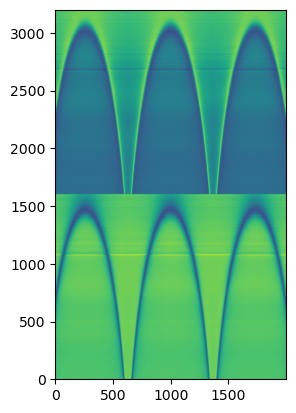

In [105]:
plt.imshow(xy_concat.transpose(),origin='lower')

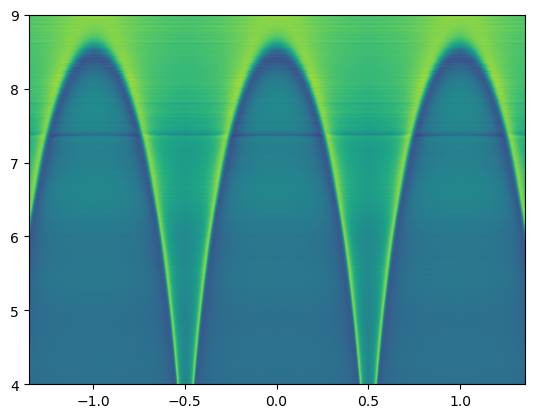

In [113]:
plt.imshow(imagxy.transpose(),origin='lower',extent = (phiwave[0], phiwave[len(phiwave)-1], fghz[0], fghz[len(fghz) - 1]),aspect='auto')

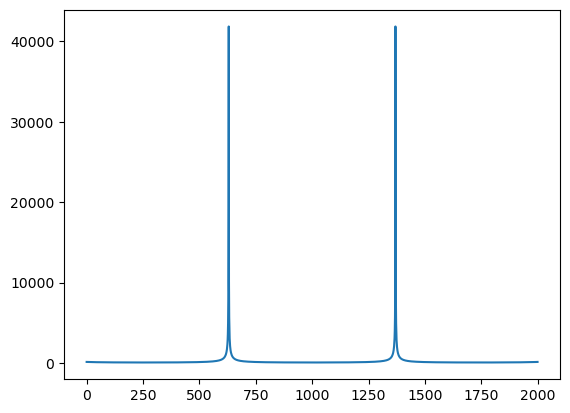

In [109]:
plt.plot(Lguesswave)

In [67]:
f_resonance = []
for index in range(len(realxy)):
    f_resonance.append(fghz[np.argmin(realxy[index])])

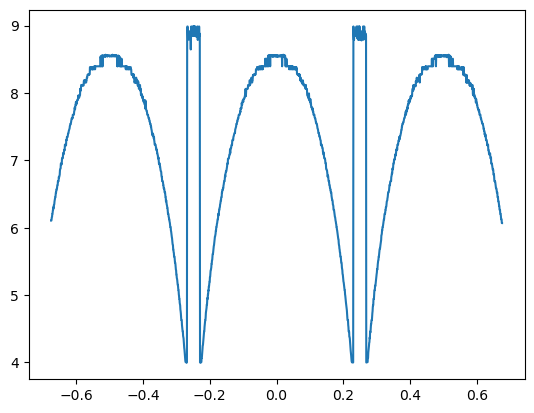

In [69]:
plt.plot(phiwave,f_resonance)

In [107]:
Lguesswave = 56/np.abs(np.cos(np.pi*phiwave))

In [91]:
phiwave[0:200]

array([-0.67567568, -0.67499966, -0.67432365, -0.67364763, -0.67297162,
       -0.67229561, -0.67161959, -0.67094358, -0.67026757, -0.66959155,
       -0.66891554, -0.66823953, -0.66756351, -0.6668875 , -0.66621148,
       -0.66553547, -0.66485946, -0.66418344, -0.66350743, -0.66283142,
       -0.6621554 , -0.66147939, -0.66080337, -0.66012736, -0.65945135,
       -0.65877533, -0.65809932, -0.65742331, -0.65674729, -0.65607128,
       -0.65539527, -0.65471925, -0.65404324, -0.65336722, -0.65269121,
       -0.6520152 , -0.65133918, -0.65066317, -0.64998716, -0.64931114,
       -0.64863513, -0.64795911, -0.6472831 , -0.64660709, -0.64593107,
       -0.64525506, -0.64457905, -0.64390303, -0.64322702, -0.64255101,
       -0.64187499, -0.64119898, -0.64052296, -0.63984695, -0.63917094,
       -0.63849492, -0.63781891, -0.6371429 , -0.63646688, -0.63579087,
       -0.63511485, -0.63443884, -0.63376283, -0.63308681, -0.6324108 ,
       -0.63173479, -0.63105877, -0.63038276, -0.62970675, -0.62

In [115]:
Cinguess = 1.5
C0guess = 6
f0ghz_360_theory = -18
Cinwave = []
C0wave = []
L0wave = []
fghz_360wave = [] 

Cinsigmawave = []
C0sigmawave = []
L0sigmawave = []
fghz_360sigmawave = [] 


for index in range(200):
    popt, pcov = curve_fit(jpa_complex_concat, fghzfghz, xy_concat[index],p0=[Cinguess,C0guess,Lguesswave[index],f0ghz_360_theory],bounds=((0.4, 2.08, 8.8, -42),(2, 10, 440, -16.8)))
    Cinwave.append(popt[0])
    C0wave.append(popt[1])
    L0wave.append(popt[2])
    fghz_360wave.append(popt[3])    
    Cinsigmawave.append(np.sqrt(pcov[0,0]))
    C0sigmawave.append(np.sqrt(pcov[1,1]))
    L0sigmawave.append(np.sqrt(pcov[2,2]))
    fghz_360sigmawave.append(np.sqrt(pcov[3,3]))

In [117]:
Cinwave = np.array(Cinwave)
C0wave = np.array(C0wave)
L0wave = np.array(L0wave)
fghz_360wave = np.array(fghz_360wave)
Cinsigmawave = np.array(Cinsigmawave)
C0sigmawave = np.array(C0sigmawave)
L0sigmawave = np.array(L0sigmawave)
fghz_360sigmawave = np.array(fghz_360sigmawave)

(0.0, 100.0)

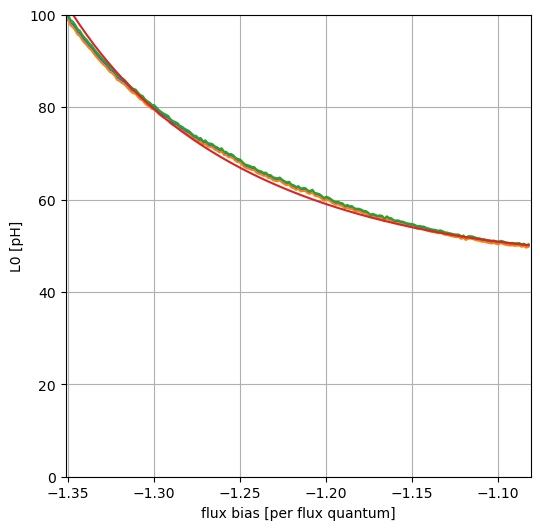

In [121]:
fig = plt.figure(figsize=(6, 6))
plt.plot(phiwave[0:200],L0wave)
plt.plot(phiwave[0:200],L0wave - L0sigmawave)
plt.plot(phiwave[0:200],L0wave + L0sigmawave)
plt.grid()
plt.xlim(phiwave[0],phiwave[200])
plt.ylabel('L0 [pH]')
plt.xlabel('flux bias [per flux quantum]')
plt.plot(phiwave[0:200],4.5 + np.abs(44.1/np.cos(np.pi*phiwave[0:200])))
plt.ylim(0,100)
#plt.xlim(-2,2)

Text(0.5, 1.0, 'line is at 1.565 pF')

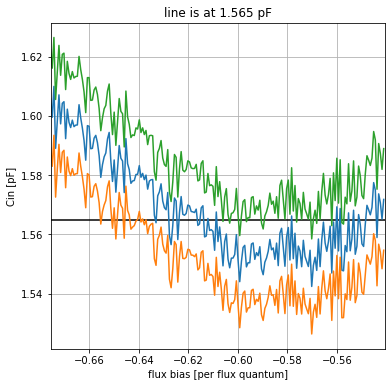

In [58]:
fig = plt.figure(figsize=(6, 6))
plt.plot(phiwave[0:200],Cinwave)
plt.plot(phiwave[0:200],Cinwave  -Cinsigmawave)
plt.plot(phiwave[0:200],Cinwave +Cinsigmawave)
plt.grid()
plt.xlim(phiwave[0],phiwave[200])
plt.ylabel('Cin [pF]')
plt.xlabel('flux bias [per flux quantum]')
plt.hlines([1.565],phiwave[0],phiwave[200],color="black")
plt.title('line is at 1.565 pF')

Text(0.5, 1.0, 'line is at -17.63 GHz')

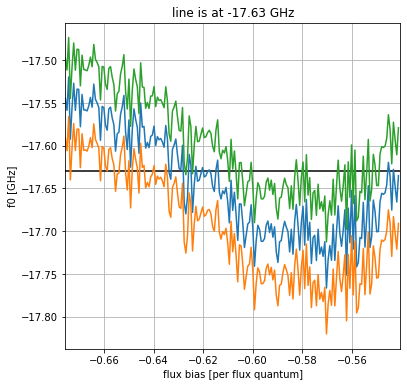

In [59]:
fig = plt.figure(figsize=(6, 6))

plt.plot(phiwave[0:200],fghz_360wave)
plt.plot(phiwave[0:200],fghz_360wave  - fghz_360sigmawave)
plt.plot(phiwave[0:200],fghz_360wave +  fghz_360sigmawave)
plt.grid()
plt.xlim(phiwave[0],phiwave[200])
plt.ylabel('f0 [GHz]')
plt.xlabel('flux bias [per flux quantum]')

plt.hlines([-17.63],phiwave[0],phiwave[200],color="black")
plt.title('line is at -17.63 GHz')

Text(0.5, 0, 'flux bias [per flux quantum]')

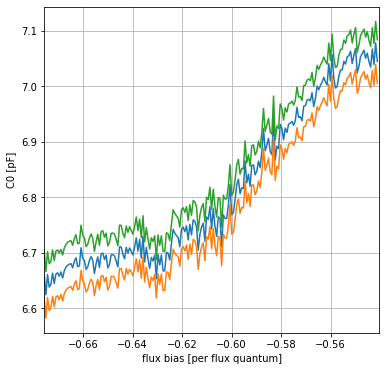

In [60]:
fig = plt.figure(figsize=(6, 6))
plt.plot(phiwave[0:200],C0wave)
plt.plot(phiwave[0:200],C0wave  - C0sigmawave)
plt.plot(phiwave[0:200],C0wave +  C0sigmawave)
plt.grid()
plt.xlim(phiwave[0],phiwave[200])
plt.ylabel('C0 [pF]')
plt.xlabel('flux bias [per flux quantum]')

fixed values


$$
Cin = 1.565 pF
$$
$$
C0 = 6.8 pF
$$
$$
L0 = 4.5 + \frac{44.1}{|\cos{(2\pi \phi/\phi_0)}|} pH
$$
$$
f0 = -17.63 GHz
$$
$$
Z_{\Sigma} = -e^{-2\pi i f /f_0}\left(\frac{1}{i\omega C_{in}} + \frac{i\omega L_0}{1 - \omega^2C_0L_0}\right) = -e^{-i\omega\tau}\left(\frac{1}{i\omega C_{in}} + \frac{i\omega L_0}{1 - (\omega/\omega_0)^2}\right)
$$
$$
\tau = 56.72 \textrm{ ps}
$$

$$
Z = \frac{1}{i\omega C_{in}} + \frac{i\omega L_0}{1 - \omega^2C_0L_0}
$$

In [12]:
f0=17.63e9

In [14]:
1e12/f0

56.72149744753261

In [7]:
def jpa_fixed(frequencyghz, phi):
    Cinlocal = 1.565e-12
    C0local = 6.8e-12
    L0local = 5.5e-12 + 44.1e-12/np.abs(np.cos(2*np.pi*phi))
    taulocal = 56.72e-12
    omega = 2*np.pi*frequencyghz*1e9
    Z_jpa = (1/(1j*omega*Cinlocal)) + (1j*omega*L0local)/(1 - omega*omega*C0local*L0local)
    s_jpa = (50 - Z_jpa)/(50 + Z_jpa)
    s_jpa = -s_jpa*np.exp(-1j*omega*taulocal)
    return s_jpa 

In [9]:
fghz

array([4.   , 4.003, 4.006, ..., 8.994, 8.997, 9.   ])

In [11]:
sfixed = []
for index in range(len(phiwave)):
    sfixed.append(jpa_fixed(fghz,phiwave[index]))
sfixed = np.array(sfixed)

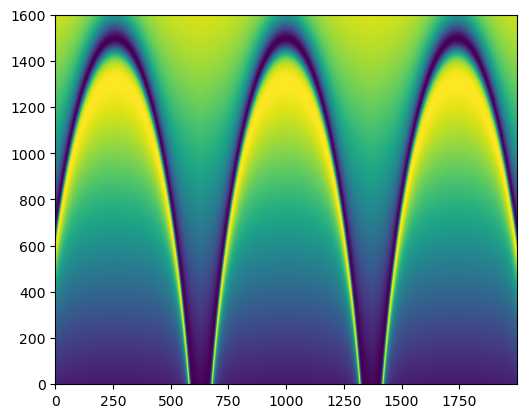

In [15]:
plt.imshow(np.real(sfixed).transpose(),origin='lower')

Text(0, 0.5, 'f [GHz]')

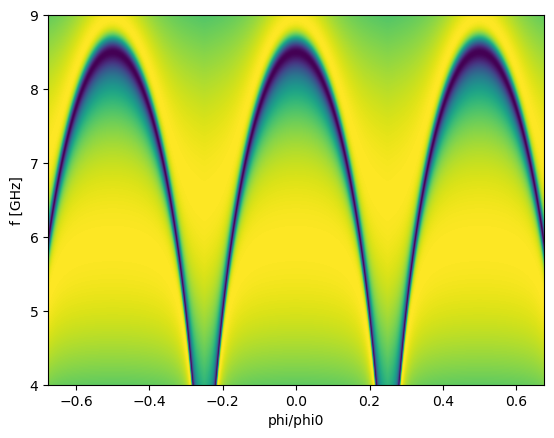

In [51]:

plt.imshow(np.imag(sfixed).transpose(),origin='lower',extent = (phiwave[0], phiwave[len(phiwave)-1], fghz[0], fghz[len(fghz) - 1]),aspect='auto')
plt.xlabel('phi/phi0')
plt.ylabel('f [GHz]')

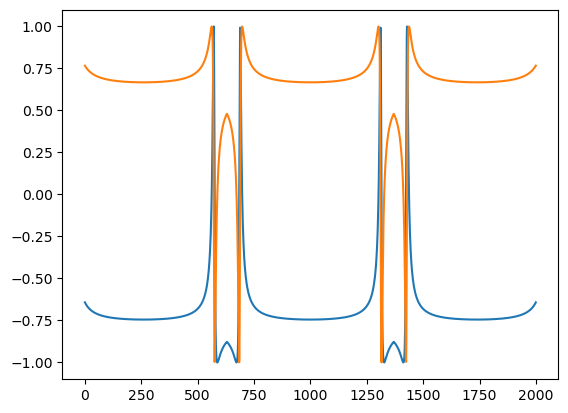

In [29]:
plt.plot(np.real(sfixed.transpose()[109]))
plt.plot(np.imag(sfixed.transpose()[109]))

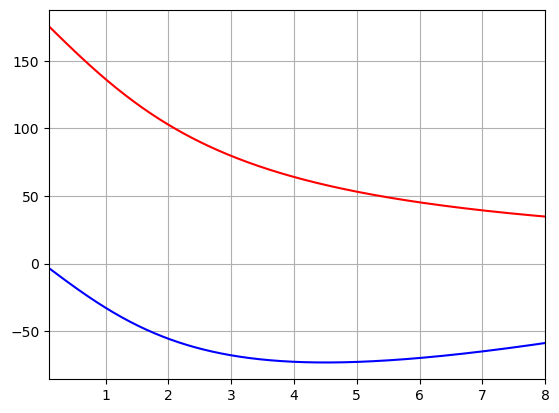

In [157]:
Cin = 1.565e-12
C0 = 6.8e-12
L0 = 75-12
fghz2= np.linspace(0.1,10,1000)
omega = 2*np.pi*fghz2*1e9
unwindtime = 30e-12
Z_jpa = (1/(1j*omega*Cin)) + (1j*omega*L0)/(1 - omega*omega*C0*L0)
s_jpa = (50 - Z_jpa)/(50 + Z_jpa)
s_jpa_unwrap = s_jpa*np.exp(-1j*np.pi)*np.exp(1j*omega*unwindtime)
plt.plot(fghz2,180*np.angle(s_jpa)/np.pi,color="red")
plt.plot(fghz2,180*np.angle(s_jpa_unwrap)/np.pi,color="blue")

plt.xlim(0.1,8)
plt.grid()